<a href="https://colab.research.google.com/github/Philmor-C/industrial-vision-system/blob/main/01_synthetic_dataset_generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import cv2
import numpy as np
import os
import random
from tqdm import tqdm
import yaml
import matplotlib.pyplot as plt

📊 Train: 113 | Val: 29


100%|██████████| 29/29 [00:06<00:00,  4.42it/s]


📄 data.yaml created at: /content/drive/MyDrive/defect_dataset/data.yaml
✅ Dataset ready!


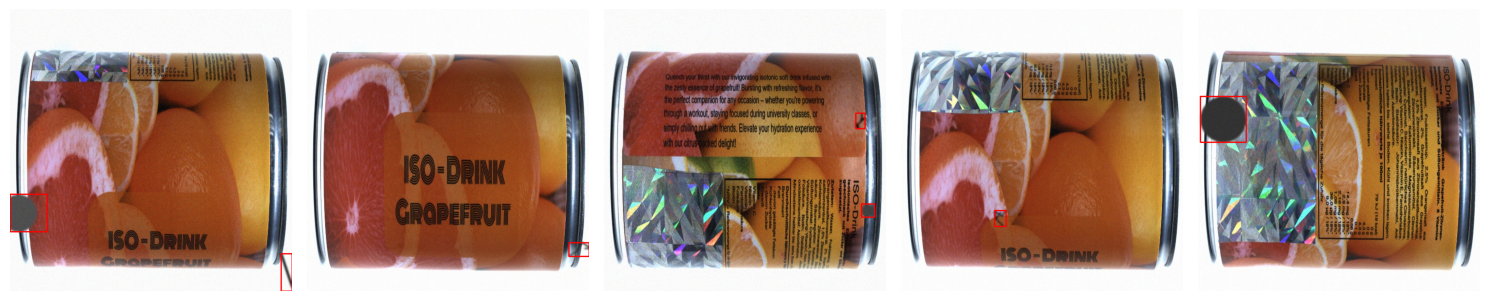

In [21]:
# -----------------------------
# CONFIG
# -----------------------------
DATASET_DIR = "/content/drive/MyDrive/good"
IMG_DIR = DATASET_DIR

BASE_DIR = "/content/drive/MyDrive/defect_dataset"

TRAIN_IMG_DIR = f"{BASE_DIR}/images/train"
VAL_IMG_DIR = f"{BASE_DIR}/images/val"

TRAIN_LABEL_DIR = f"{BASE_DIR}/labels/train"
VAL_LABEL_DIR = f"{BASE_DIR}/labels/val"

IMG_SIZE = 640

os.makedirs(TRAIN_IMG_DIR, exist_ok=True)
os.makedirs(VAL_IMG_DIR, exist_ok=True)
os.makedirs(TRAIN_LABEL_DIR, exist_ok=True)
os.makedirs(VAL_LABEL_DIR, exist_ok=True)


# -----------------------------
# SURFACE AWARENESS
# -----------------------------
def get_surface_mask(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)

    kernel = np.ones((5, 5), np.uint8)
    return cv2.dilate(edges, kernel, iterations=2)


def sample_valid_point(surface_mask):
    ys, xs = np.where(surface_mask > 0)

    if len(xs) == 0:
        h, w = surface_mask.shape
        return random.randint(0, w - 1), random.randint(0, h - 1)

    idx = random.randint(0, len(xs) - 1)
    return xs[idx], ys[idx]


# -----------------------------
# DEFECT TYPES
# -----------------------------
def create_scratch(img_shape, surface_mask):
    h, w = img_shape[:2]
    mask = np.zeros((h, w), np.uint8)

    x, y = sample_valid_point(surface_mask)

    length = random.randint(40, 120)
    angle = random.uniform(0, np.pi)

    x2 = int(x + length * np.cos(angle))
    y2 = int(y + length * np.sin(angle))

    cv2.line(mask, (x, y), (x2, y2), 255, thickness=random.randint(1, 3))

    x, y, bw, bh = cv2.boundingRect(np.array([[x, y], [x2, y2]]))
    return mask, (x, y, bw, bh), 0


def create_crack(img_shape, surface_mask):
    h, w = img_shape[:2]
    mask = np.zeros((h, w), np.uint8)

    points = []
    x, y = sample_valid_point(surface_mask)

    for _ in range(random.randint(6, 12)):
        x += random.randint(-20, 20)
        y += random.randint(-20, 20)
        points.append([x, y])

    points = np.array(points, np.int32)

    cv2.polylines(mask, [points], False, 255, thickness=2)

    x, y, bw, bh = cv2.boundingRect(points)
    return mask, (x, y, bw, bh), 1


def create_dent(img_shape, surface_mask):
    h, w = img_shape[:2]
    mask = np.zeros((h, w), np.uint8)

    x, y = sample_valid_point(surface_mask)
    r = random.randint(15, 60)

    cv2.circle(mask, (x, y), r, 255, -1)

    return mask, (x - r, y - r, r * 2, r * 2), 2


# -----------------------------
# BLENDING (FIXED)
# -----------------------------
def apply_realistic_defect(img, mask, class_id):
    mask_blur = cv2.GaussianBlur(mask, (11, 11), 0)
    mask_norm = mask_blur.astype(np.float32) / 255.0
    mask_3 = np.stack([mask_norm] * 3, axis=-1)

    if class_id == 0:
        color = np.random.randint(0, 60)
    elif class_id == 1:
        color = np.random.randint(0, 40)
    else:
        color = np.random.randint(30, 120)

    defect_layer = np.full_like(img, color).astype(np.float32)

    out = img.astype(np.float32) * (1 - mask_3) + defect_layer * mask_3

    noise = np.random.normal(0, 5, img.shape).astype(np.float32)
    out = np.clip(out + noise, 0, 255)

    return out.astype(np.uint8)


# -----------------------------
# YOLO FORMAT (FIXED)
# -----------------------------
def to_yolo(x, y, w, h, img_w, img_h):
    x_center = (x + w / 2) / img_w
    y_center = (y + h / 2) / img_h
    w = w / img_w
    h = h / img_h
    return x_center, y_center, w, h


# -----------------------------
# PROCESS IMAGE
# -----------------------------
def process_image(path, idx, split="train"):
    img = cv2.imread(path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    surface_mask = get_surface_mask(img)

    h, w = img.shape[:2]
    labels = []

    num_defects = random.randint(1, 2)

    for _ in range(num_defects):
        defect_type = random.choice(["scratch", "crack", "dent"])

        if defect_type == "scratch":
            mask, (x, y, bw, bh), cls = create_scratch(img.shape, surface_mask)
        elif defect_type == "crack":
            mask, (x, y, bw, bh), cls = create_crack(img.shape, surface_mask)
        else:
            mask, (x, y, bw, bh), cls = create_dent(img.shape, surface_mask)

        x = max(0, x)
        y = max(0, y)
        bw = min(bw, w - x)
        bh = min(bh, h - y)

        img = apply_realistic_defect(img, mask, cls)

        x_c, y_c, bw_n, bh_n = to_yolo(x, y, bw, bh, w, h)
        labels.append(f"{cls} {x_c} {y_c} {bw_n} {bh_n}")

    if split == "train":
        img_out = f"{TRAIN_IMG_DIR}/img_{idx}.jpg"
        label_out = f"{TRAIN_LABEL_DIR}/img_{idx}.txt"
    else:
        img_out = f"{VAL_IMG_DIR}/img_{idx}.jpg"
        label_out = f"{VAL_LABEL_DIR}/img_{idx}.txt"

    cv2.imwrite(img_out, img)

    with open(label_out, "w") as f:
        f.write("\n".join(labels))


# -----------------------------
# DATA.YAML GENERATOR
# -----------------------------
def create_data_yaml():
    yaml_path = os.path.join(BASE_DIR, "data.yaml")

    data = {
        "path": BASE_DIR,
        "train": "images/train",
        "val": "images/val",
        "names": {
            0: "scratch",
            1: "crack",
            2: "dent"
        }
    }

    with open(yaml_path, "w") as f:
        yaml.dump(data, f, sort_keys=False)

    print(f"📄 data.yaml created at: {yaml_path}")


# -----------------------------
# VISUALIZATION
# -----------------------------
def visualize_random_samples(n=5):
    img_files = os.listdir(TRAIN_IMG_DIR)
    selected = random.sample(img_files, min(n, len(img_files)))

    plt.figure(figsize=(15, 5))

    for i, img_name in enumerate(selected):
        img_path = os.path.join(TRAIN_IMG_DIR, img_name)
        label_path = os.path.join(TRAIN_LABEL_DIR, img_name.replace(".jpg", ".txt"))

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        h, w = img.shape[:2]

        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                for line in f.readlines():
                    cls, xc, yc, bw, bh = map(float, line.strip().split())

                    x1 = int((xc - bw/2) * w)
                    y1 = int((yc - bh/2) * h)
                    x2 = int((xc + bw/2) * w)
                    y2 = int((yc + bh/2) * h)

                    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# -----------------------------
# MAIN PIPELINE
# -----------------------------
def main():
    images = [f for f in os.listdir(IMG_DIR)
              if f.lower().endswith((".jpg", ".png", ".jpeg"))]

    random.shuffle(images)

    split_idx = int(0.8 * len(images))
    train_imgs = images[:split_idx]
    val_imgs = images[split_idx:]

    print(f"📊 Train: {len(train_imgs)} | Val: {len(val_imgs)}")

    for i, img_name in enumerate(tqdm(train_imgs)):
        process_image(os.path.join(IMG_DIR, img_name), i, "train")

    for i, img_name in enumerate(tqdm(val_imgs)):
        process_image(os.path.join(IMG_DIR, img_name), i, "val")

    create_data_yaml()

    print("✅ Dataset ready!")
    visualize_random_samples(5)


if __name__ == "__main__":
    main()